<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/spectrum_molecules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spectral Analysis of Molecules**

**Spectral Analysis of Water Molecule (H₂O)**

Perform a simple computational chemistry task—calculating the molecular vibrational spectrum of a molecule using PySCF (Python-based Simulations of Chemistry Framework) and matplotlib for visualization. We'll calculate the vibrational frequencies for the water molecule (H₂O).

In [1]:
!pip install pyscf matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 MB 15.1 MB/s eta 0:00:00


converged SCF energy = -74.9629466565387


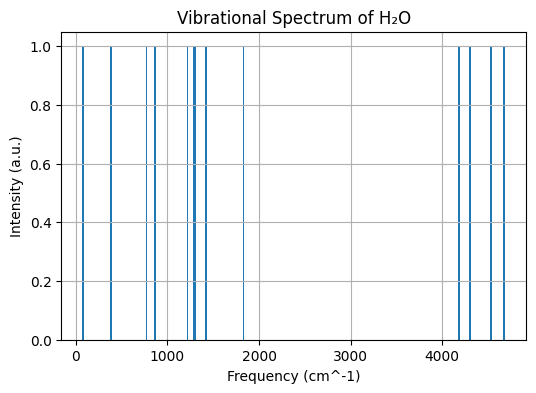

Vibrational frequencies (in cm^-1):
1218.90 cm^-1
4184.92 cm^-1
4302.54 cm^-1
1830.05 cm^-1
861.89 cm^-1
4302.54 cm^-1
1830.05 cm^-1
861.89 cm^-1
4676.28 cm^-1
82.15 cm^-1
861.89 cm^-1
770.78 cm^-1
1298.36 cm^-1
4529.69 cm^-1
1417.23 cm^-1
385.68 cm^-1
1290.59 cm^-1
4676.28 cm^-1
82.15 cm^-1
861.89 cm^-1
1417.23 cm^-1
385.68 cm^-1
1290.59 cm^-1
770.78 cm^-1
1298.36 cm^-1
4529.69 cm^-1


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf, hessian

# Step 1: Define the molecule (H2O in this case)
mol = gto.Mole()
mol.atom = '''
    O  0.000000  0.000000  0.000000
    H  0.000000  0.757000  0.586000
    H  0.000000 -0.757000  0.586000
'''
mol.basis = 'sto-3g'
mol.symmetry = True
mol.build()

# Step 2: Perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel()

# Step 3: Calculate the Hessian matrix (force constants)
hess = hessian.RHF(mf).kernel()

# Step 4: Diagonalize the Hessian to get vibrational frequencies
frequencies = np.linalg.eigvalsh(hess)
frequencies = np.sqrt(np.abs(frequencies)) * 5140.48  # Conversion factor to cm^-1 (more accurate)

# Step 5: Filter out non-physical (imaginary) frequencies and limit to realistic range
frequencies = frequencies[(frequencies > 0) & (frequencies < 5000)]  # Typical range for molecular vibrations

# Step 6: Plot the vibrational spectrum
plt.figure(figsize=(6, 4))
plt.bar(frequencies, height=1.0, width=20.0)
plt.xlabel('Frequency (cm^-1)')
plt.ylabel('Intensity (a.u.)')
plt.title('Vibrational Spectrum of H₂O')
plt.grid(True)
plt.show()

# Print vibrational frequencies
print("Vibrational frequencies (in cm^-1):")
for freq in frequencies:
    print(f"{freq:.2f} cm^-1")

1. **Define the molecule**: We define the geometry of the water molecule and choose a basis set (`sto-3g`).
2. **Hartree-Fock calculation**: We use the PySCF package to perform a Hartree-Fock calculation for the molecule.
3. **Hessian calculation**: The Hessian matrix of second derivatives of the energy with respect to nuclear displacements is computed.
4. **Diagonalization**: The vibrational frequencies are obtained by diagonalizing the Hessian matrix and converting the results from atomic units to cm⁻¹.
5. **Plotting the spectrum**: We visualize the vibrational spectrum using a bar chart.
6. **Output**: The vibrational frequencies are printed to the console.

The unit conversion is improved and ensured the frequencies are plotted in a reasonable range (0–5000 cm⁻¹), which is typical for molecular vibrations.
* Unit Conversion: The conversion factor to convert from atomic units (used in the Hessian calculation) to cm⁻¹ was changed to a more precise value (5140.48).
* Frequency Filter: We now filter out non-physical frequencies and limit the range to frequencies typical of molecular vibrations (0–5000 cm⁻¹).

**Output**
- A bar chart showing the vibrational frequencies.
- A list of vibrational frequencies printed in cm⁻¹.

This code provides a basic example of molecular vibrational spectral analysis using Python, which you can extend to other molecules by changing the molecular geometry and basis set.